In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("../../DataSets/RegData_new.csv")

In [10]:
data.describe()

,Unnamed: 0,StID,SAT,GPA
count,81.000000,81.000000,81.000000,81.000000
mean,41.049383,149.049383,1350.185185,3.361481
std,24.604827,29.747227,102.931666,0.220738
min,0.000000,101.000000,1134.000000,2.740000
25%,20.000000,122.000000,1275.000000,3.210000
50%,41.000000,149.000000,1350.000000,3.390000
75%,62.000000,175.000000,1434.000000,3.510000
max,83.000000,198.000000,1550.000000,3.810000


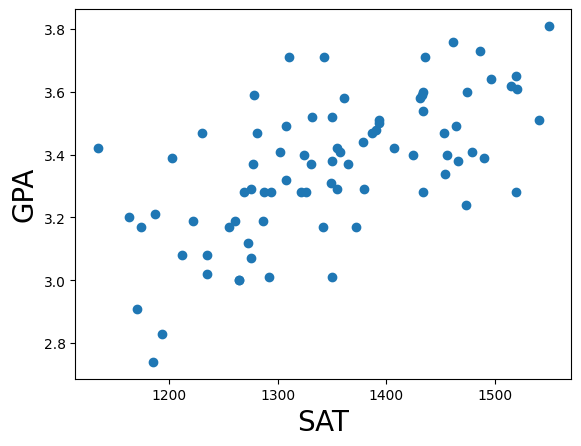

In [11]:
y = data ['GPA']
x = data ['SAT']
plt.scatter(x,y)
plt.xlabel ('SAT', fontsize = 20)
plt.ylabel ('GPA', fontsize = 20)
plt.show()

In [12]:
data[['SAT','GPA']].corr()

,SAT,GPA
SAT,1.000000,0.634194
GPA,0.634194,1.000000


In [13]:
import seaborn as sns

<Axes: >

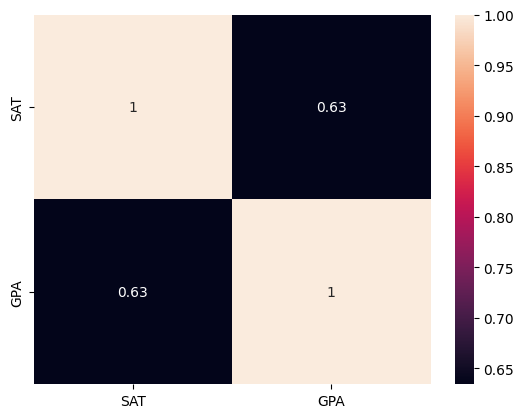

In [14]:
sns.heatmap(data[['SAT', 'GPA']].corr(),annot = True)

In [15]:
from scipy.stats import linregress

In [16]:
slope, intercept, r_value, p_value, std_err = linregress(x,y)

In [17]:
print ("Slope:", slope)
print("Intercept", intercept)

Slope: 0.0013600349643199277
Intercept 1.5251824213228533


In [18]:
y1 = slope*x + intercept

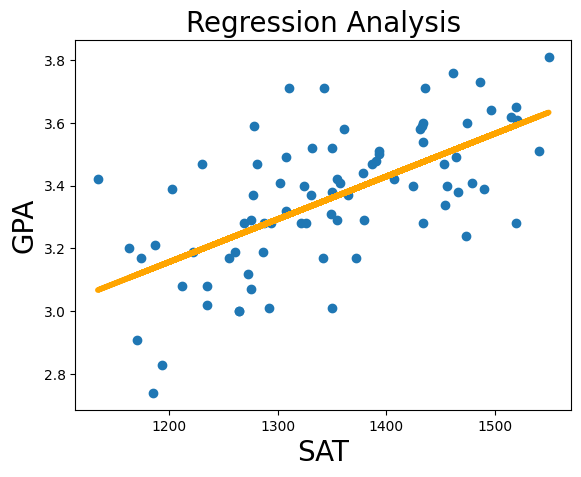

In [19]:
plt.scatter(x,y)

fig  = plt.plot(x,y1, lw=4, c='orange', label = 'regression line')
plt.title("Regression Analysis", fontsize = 20)
plt.xlabel('SAT', fontsize = 20)
plt.ylabel('GPA', fontsize = 20)
plt.show()

FIND THE PREDICTED VALUE OF UNSEEN DATA

In [20]:
givenSAT = 1450
predGPA = slope * givenSAT + intercept
predGPA

np.float64(3.4972331195867485)

ACTUAL VS PREDICTED

In [21]:
df_p = pd.DataFrame({"ActualGPA":y, "PredictedGPA":y1})
df_p.head()

,ActualGPA,PredictedGPA
0,3.42,3.368030
1,3.48,3.416991
2,2.91,3.116423
3,3.41,3.370750
4,3.28,3.328589


<Axes: >

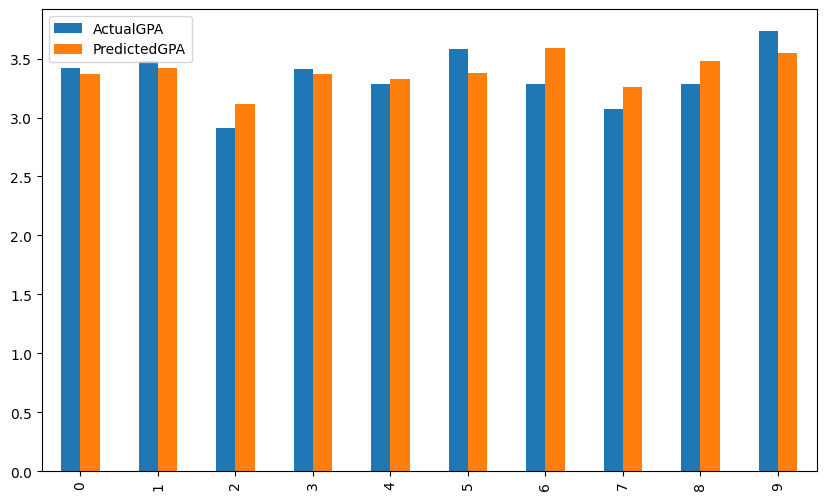

In [22]:
df_p.head(10).plot(kind="bar", figsize=(10,6))

In [23]:
df_a_p = pd.DataFrame({**data,"PredictedGPA":y1})
df_a_p.head()

,Unnamed: 0,StID,SAT,GPA,PredictedGPA
0,0,101,1355,3.42,3.368030
1,1,102,1391,3.48,3.416991
2,2,103,1170,2.91,3.116423
3,3,104,1357,3.41,3.370750
4,4,105,1326,3.28,3.328589


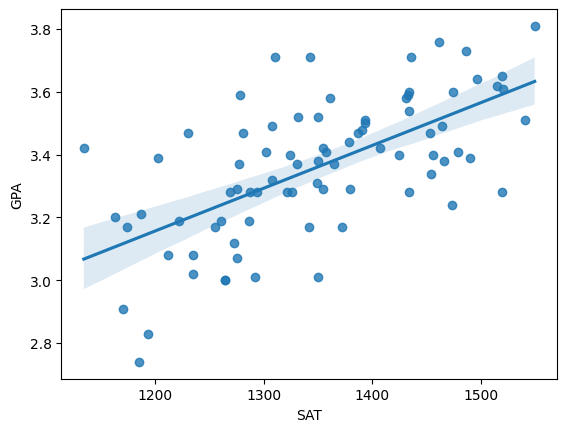

In [24]:
import seaborn as sns
p = sns.regplot(data=data, x=data.SAT, y=data.GPA)

<Axes: xlabel='SAT', ylabel='GPA'>

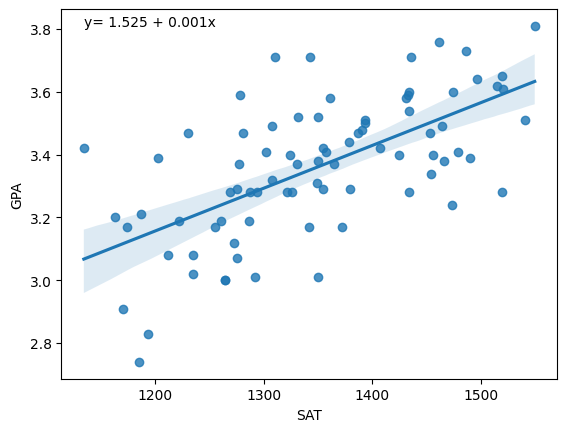

In [25]:
#add regression equvation to plot
plt.text(min(data.SAT), max(data.GPA), 'y= ' + str(round(intercept,3)) + ' + ' + str(round(slope,3)) + 'x')
sns.regplot(data=data, x=data.SAT, y=data.GPA)

In [26]:
#split data
from sklearn.model_selection import train_test_split

In [27]:
x = data.SAT
y = data.GPA

# split data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# reshape for sklearn
X_train = X_train.to_numpy().reshape(-1, 1)
X_test = X_test.to_numpy().reshape(-1, 1)

In [28]:
from sklearn.linear_model import LinearRegression
rgsr= LinearRegression()

In [29]:
#fit a model
model =rgsr.fit(X_train,y_train)

In [30]:
#make prediction on test set
y_pred = model.predict(X_test)

In [31]:
y= pd.DataFrame({'Original': y_test , 'Predicted':y_pred})
y.head()

,Original,Predicted
63,3.76,3.504437
27,3.65,3.573986
31,3.19,3.293393
69,3.00,3.267013
46,3.17,3.159093


Evaluation Indicators

In [32]:
from sklearn import metrics

In [33]:
print ('Evaluation indicators')
print ("MAE:\t", metrics.mean_absolute_error(y_test,y_pred) )
print ("MSE:\t", metrics.mean_squared_error(y_test,y_pred) )
print ("RMSE:\t", metrics.mean_squared_error(y_test,y_pred)**(0.5))
print ("R-Squared", metrics.r2_score(y_test,y_pred) )

Evaluation indicators
MAE:	 0.1364566158325926
MSE:	 0.030593767925858665
RMSE:	 0.17491074274000057
R-Squared 0.5115887530482646


Applying Gradient Decent

In [34]:
import numpy as np

In [35]:
#1. Initialize parameters
b0 = 0.0
b1 = 0.0
learning_rate = 0.00000001 #small alpha because SAT scores are large
epochs = 1000 # Number of iterations
n = float (len(X_train)) # Number of elements in X_train

In [36]:
#Ensure X_train and y_train are flattened for calculation
x_vals = X_train.flatten()
y_vals = y_train.to_numpy()

In [37]:
#2 The Gradient Descent Loop
for i in range (epochs):
  # Current Prediction
    y_current = b1 * x_vals +b0

    #Calculate Gradient (Partial dERIVATIES)
    #D_b1 = -2/n * sum(x * (y_actual - y_ predicted))
    #D_b0 = -2/n * sum(y_actual -y_predicted)
    D_b1 =(-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 =(-2/n) * sum(y_vals - y_current)

    #Update Parameters

    b1= b1 - learning_rate * D_b1
    b0= b0 - learning_rate * D_b0

print(f"Final intercept (b0): {b0}")
print(f"Final Slope (b1): {b1}")

Final intercept (b0): 2.0266199485581157e-06
Final Slope (b1): 0.0024965278664366656


In [38]:
#3 Make pReduction for test set
y_pred_gd = b1* X_test.flatten() +b0

In [39]:
from sklearn import metrics

print ('---Gradient Descent Evaluation---')
print ("MAE:\t", metrics.mean_absolute_error(y_test,y_pred_gd) )
print ("MSE:\t", metrics.mean_squared_error(y_test,y_pred_gd) )
print ("RMSE:\t", metrics.mean_squared_error(y_test,y_pred_gd)**(0.5))
print ("R-Squared", metrics.r2_score(y_test,y_pred_gd) )

---Gradient Descent Evaluation---
MAE:	 0.1618289718218592
MSE:	 0.03878285899534227
RMSE:	 0.19693364109603587
R-Squared 0.38085480127283766
